## Pair Trading

In [128]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm

In [148]:
data = yf.download(['EWA', 'EWC'] , start='2015-1-1', end='2020-1-1')['Close']
data.head()

[*********************100%***********************]  2 of 2 completed


Ticker,EWA,EWC
Date,,
2010-01-04,11.784902,19.209446
2010-01-05,11.819679,19.316481
2010-01-06,11.864393,19.466330
2010-01-07,11.809744,19.402113
2010-01-08,11.948857,19.502010


In [149]:
data.columns = data.columns.get_level_values(0)
data.head()

Ticker,EWA,EWC
Date,,
2010-01-04,11.784902,19.209446
2010-01-05,11.819679,19.316481
2010-01-06,11.864393,19.466330
2010-01-07,11.809744,19.402113
2010-01-08,11.948857,19.502010


### Test for cointegration

In [150]:
ewa = data['EWA'].dropna()
ewc = data['EWC'].dropna()
ewa, ewc = ewa.align(ewc, join='inner')

ewa = np.log(ewa)
ewc = np.log(ewc)
score, p_value, _ = coint(ewa,ewc)

In [151]:
result = 'Contegrated' if p_value < 0.05 else 'Not cointegrated'
print(f"p-value {p_value}, {result}")

p-value 0.5935551283852759, Not cointegrated


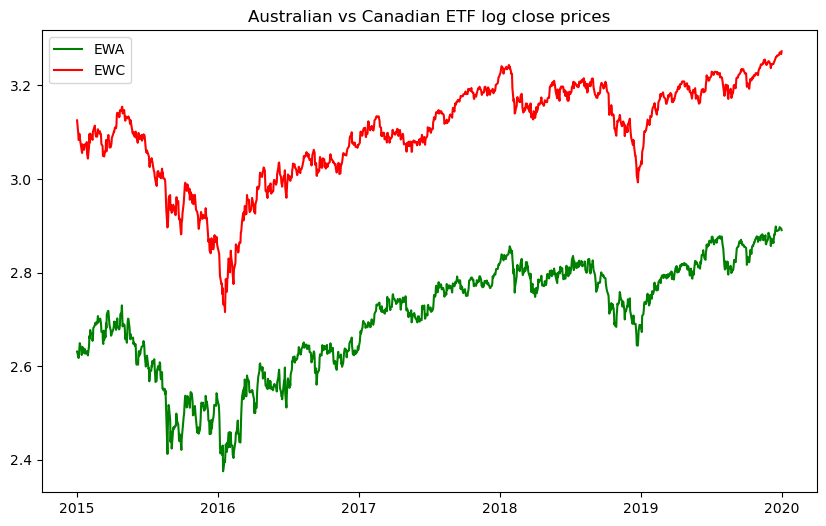

In [144]:
plt.figure(figsize=(10, 6))
plt.plot(ewa, label='EWA', color='green')
plt.plot(ewc, label='EWC', color='red')
plt.title('Australian vs Canadian ETF log close prices')
plt.legend()
plt.show()

In [142]:
ewc_costant = sm.add_constant(ewc)
model = sm.OLS(ewa,ewc_costant).fit()
# results = model
# results.summary()
hedge_ratio = model.params['EWC']
print(f"Hedge ratio: {hedge_ratio}")

Hedge ratio: 1.0867361322616356


Sharpe Ratio: 0.9127
Total Return: 1.7091


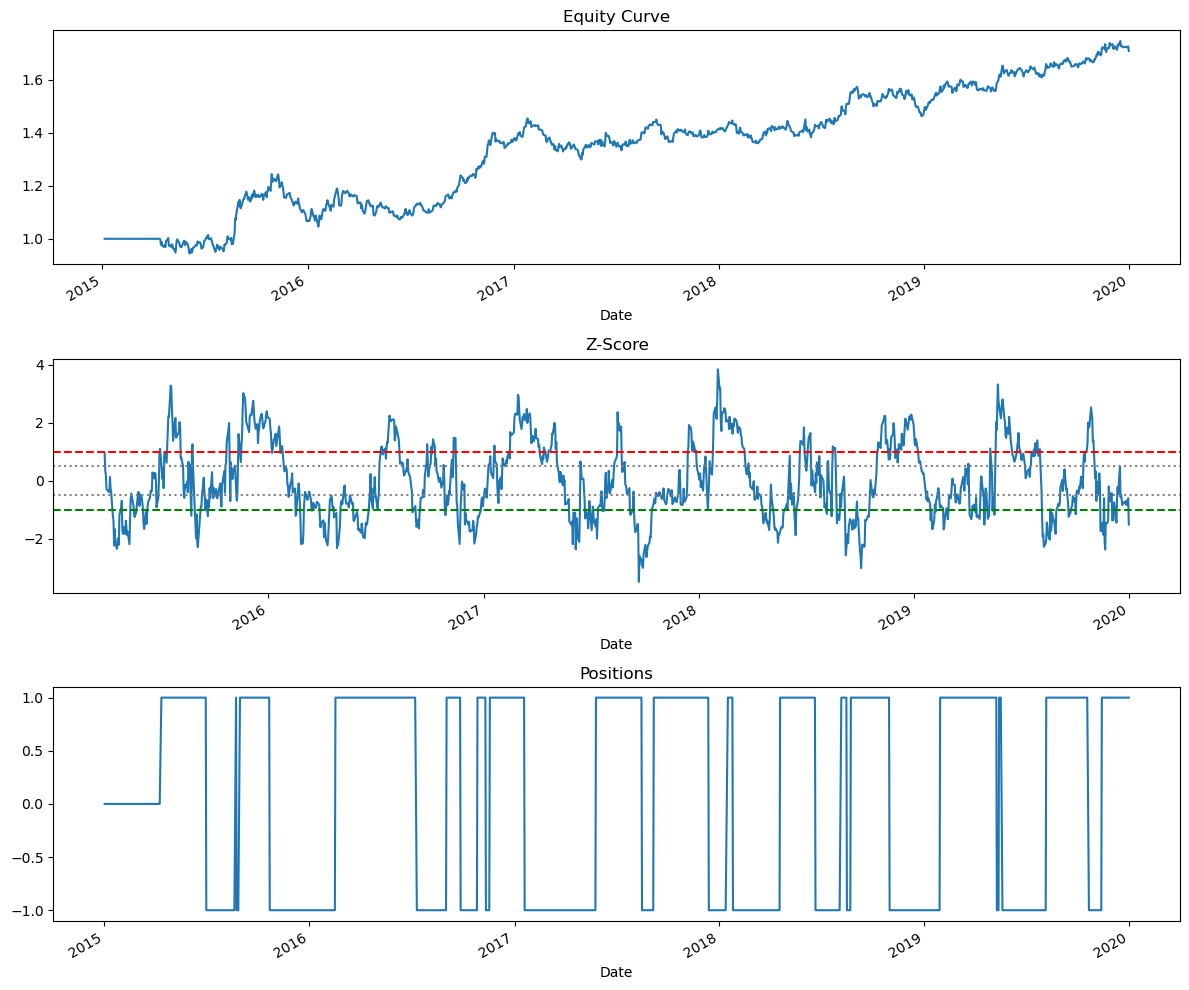

In [143]:
# Construct spread and Z-score
spread = ewa - hedge_ratio * ewc
spread_mean = spread.rolling(window=60).mean()
spread_std = spread.rolling(window=60).std()
zscore = (spread - spread_mean) / spread_std

# Generate signals
signals = pd.Series(0, index=spread.index)
signals[zscore < -1] = 1    # spread too low, go long
signals[zscore > 1] = -1    # spread too high, go short
signals[zscore.abs() < 0.5] = 0  # exit zone

# Forward fill to hold position
signals = signals.replace(0, np.nan).ffill().fillna(0)

# Calculate strategy returns
spread_returns = spread.diff()
strategy_returns = signals.shift(1) * spread_returns

# Performance
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)
cumulative = (1 + strategy_returns).cumprod()

print(f"Sharpe Ratio: {sharpe:.4f}")
print(f"Total Return: {cumulative.iloc[-1]:.4f}")

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
cumulative.plot(ax=axes[0], title='Equity Curve')
zscore.plot(ax=axes[1], title='Z-Score')
axes[1].axhline(1, color='r', linestyle='--')
axes[1].axhline(-1, color='g', linestyle='--')
axes[1].axhline(0.5, color='gray', linestyle=':')
axes[1].axhline(-0.5, color='gray', linestyle=':')
signals.plot(ax=axes[2], title='Positions')
plt.tight_layout()
plt.show()

EWA/EWC
- Cointegrated: 2015-2020 (p = your value)
- Not cointegrated: 2010-2015
- In-sample Sharpe (2015-2020, log prices): 0.91
- Out-of-sample: relationship absent, strategy not applicable
- Conclusion: regime-dependent pair, tied to commodity cycle synchronization